# **Problem Description**

---



# **Reinforcement Learning (RL) and OpenAI Gym**

*   The set of tasks that can be solved using the means of
reinforcement learning tools is quite broad, and each of these tasks may
have its own code implementation.
*   At the same time, various RL techniques
can be applied to any RL problem.
*   But at this point, an applicability
problem may arise since each task can have its own implementation, and it
can be quite challenging to implement a specific RL algorithm in a
particular situation.
* Gym solves this problem by unifying all reinforcement
learning tasks.
* OpenAI Gym is a free Python toolkit that provides developers with an environment for developing and testing learning agents for deep learning models.

# **Benefits of Gym**

Gymnasium is a standardized API for reinforcement learning environments.

It allows us to:
* Build RL agents
* Test algorithms
* Benchmark results
* Ensure reproducibility
* Compare performance across environments

Gymnasium is the maintained successor of OpenAI Gym.


* Gym unifies the process of testing solutions to reinforcement learning
problems.
* Each RL problem can have its own unique solution, which will
allow the agent to maximize rewards.
* It is often helpful to test several predesigned
RL algorithms and see which one performs the best. Such brute
force technique can provide a useful direction for developing your own
solution or possibly applying an existing one.
* The Gym toolkit offers a
standard interface for all RL problems, which allows you to test various
solution production-ready algorithms.

# ***Key Concept of RL***

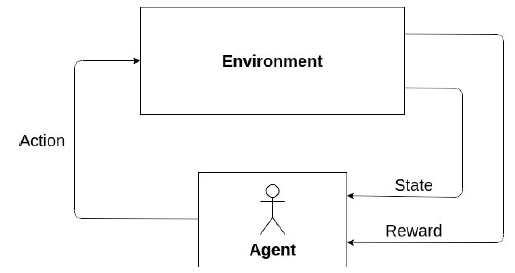

* **Agent** is a decision-maker who defines what action to take.
  **Examples:** Self-driving car, chess player, stock trading robot
* **Action** is a concrete act in a surrounding environment that is taken by the
agent. **Examples:** Turn car left, move chess pawn one cell forward, sell all
assets
* **Environment** is a problem context that the agent cooperates with. **Examples:** Car track, chess board, stock market
* **State** is a position of the agent in the environment. **Examples:** Car coordinates on the track and its speed, arrangement of pieces on the chessboard, price of assets
* **Reward** is a numerical value returned by an environment as the reaction
to the agent's action. **Example:** To reach a goal on the car without any accidents, to win chess play, to earn more money



In Reinforcement Learning:

* Agent interacts with Environment
* Agent takes Action
* Environment returns:
  * New State
  * Reward
  * Done signal

The objective is to maximize cumulative reward.

# **Execution**

---



# **Working With Gym**

Step 1: **Gym Installation:** Install gym and give instruction for the output to be displayed in standard output

In [ ]:
pip install gymnasium  # For using gymnasium

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 965 kB 1.2 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install pygame  # For rendering the environment

***To view the existing Environments in Gym***

In [ ]:
from gym import envs
for e in envs.registry.values():
    print(e.id)

CartPole-v0
CartPole-v1
MountainCar-v0
MountainCarContinuous-v0
Pendulum-v1
Acrobot-v1
LunarLander-v2
LunarLanderContinuous-v2
BipedalWalker-v3
BipedalWalkerHardcore-v3
CarRacing-v2
Blackjack-v1
FrozenLake-v1
FrozenLake8x8-v1
CliffWalking-v0
Taxi-v3
Reacher-v2
Reacher-v4
Pusher-v2
Pusher-v4
InvertedPendulum-v2
InvertedPendulum-v4
InvertedDoublePendulum-v2
InvertedDoublePendulum-v4
HalfCheetah-v2
HalfCheetah-v3
HalfCheetah-v4
Hopper-v2
Hopper-v3
Hopper-v4
Swimmer-v2
Swimmer-v3
Swimmer-v4
Walker2d-v2
Walker2d-v3
Walker2d-v4
Ant-v2
Ant-v3
Ant-v4
Humanoid-v2
Humanoid-v3
Humanoid-v4
HumanoidStandup-v2
HumanoidStandup-v4


***To realise the working of RL and its concepts, we will see how it is implemented in real time using Gym.***

The Acrobot environment consists of two links connected linearly to form a chain, with one end of the chain fixed. The joint between the two links is actuated. The goal is to apply torques on the actuated joint to swing the free end of the linear chain above a given height while starting from the initial state of hanging downwards.

As seen in the gif below: two blue links connected by two green joints. The joint in between the two links is actuated. The goal is to swing the free end of the outer-link to reach the target height (black horizontal line above system) by applying torque on the actuator.

![AcrobatURL](https://gymnasium.farama.org/_images/acrobot.gif)

Import the sleep function from the time module, allowing for pauses in the code execution.

---


Import the Gym library, which provides a collection of environments to test reinforcement learning algorithms.

---


Import the random module, used for generating random numbers.

In [ ]:
# Installing and importing
import gymnasium as gym
import numpy as np
import time
import matplotlib.pyplot as plt
import pygame
import random

Initialize the seed variable.

Set the seed for the random number generator in the random module to ensure reproducibility. In other words, using this parameter makes sure that anyone who re-runs your code will get the exact same outputs.

Set the seed for Gym's environment to maintain consistency in the environment's behavior across runs.

Environment Initialization -

* Acrobot is a 2-link pendulum system:
    * Only the second joint is actuated
    * First joint is passive
    * Goal: Swing the end of the lower link to a given height
    * It is a classic control problem in RL.


Create an instance of the Acrobat environment named env using Gym's make function. The 'Acrobot-v1' environment simulates a 2 link pendulum with joints, with the goal of making the lower link reach the given height.

In [ ]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")

In [ ]:
seed = 0

env.reset(seed=42)
np.random.seed(42)

Inspecting and understanding the environment

In [ ]:
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action Space: Discrete(3)


State vector has 6 values:

| Index | Meaning                     |
| ----- | --------------------------- |
| 0     | cos(theta1)                 |
| 1     | sin(theta1)                 |
| 2     | cos(theta2)                 |
| 3     | sin(theta2)                 |
| 4     | Angular velocity of joint 1 |
| 5     | Angular velocity of joint 2 |


Angles are encoded using sine and cosine to avoid discontinuity.

Action Space has 3 discrete values.

| Action | Meaning               |
| ------ | --------------------- |
| 0      | Apply negative torque |
| 1      | Apply zero torque     |
| 2      | Apply positive torque |


### Resetting the environment and seeing initial values

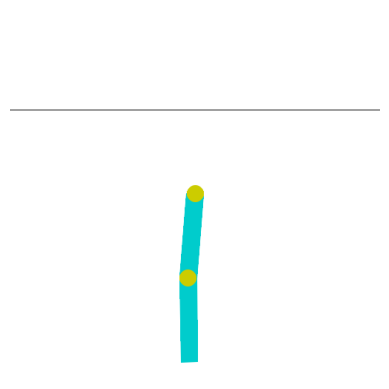

Initial State:
 [ 0.996708   -0.08107544  0.9954791   0.09498107  0.05222794  0.05721286]
State Shape: (6,)


In [ ]:
state, info = env.reset()

frame = env.render()

plt.imshow(frame)
plt.axis("off")
plt.show()

print("Initial State:\n", state)
print("State Shape:", state.shape)

* state → Initial observation
* info → Debugging dictionary

### Taking a Single Step

In [ ]:
action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Next State:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)

Next State: [ 0.9973573  -0.07265235  0.9923851   0.123174    0.03154354  0.22259767]
Reward: -1.0
Terminated: False
Truncated: False


* Episode ends when:
    * done = terminated or truncated
    * terminated → Goal achieved or failure
    * truncated → Time limit reached

### Reward Structure

* In Acrobot:
    * Reward = -1 at every step
    * Episode ends when goal height is reached
    * So agent tries to finish in minimum steps.
    * This is called a sparse negative reward structure.

### Full Random Agent Implementation

In [ ]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")

state, info = env.reset()

done = False
total_reward = 0
step_count = 0

while not done:

    # Random action
    action = env.action_space.sample()

    # Take step
    next_state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    total_reward += reward
    step_count += 1

    state = next_state

    # Slow down rendering for visibility
    time.sleep(0.02)

print("Episode Finished")
print("Total Reward:", total_reward)
print("Total Steps:", step_count)

env.close()

Episode Finished
Total Reward: -500.0
Total Steps: 500


### Exploring Multiple Episodes

In [ ]:
env = gym.make("Acrobot-v1",render_mode="rgb_array")

episodes = 5

for episode in range(episodes):

    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        state = next_state

    print(f"Episode {episode+1} Total Reward: {total_reward}")

env.close()

Episode 1 Total Reward: -500.0
Episode 2 Total Reward: -500.0
Episode 3 Total Reward: -500.0
Episode 4 Total Reward: -500.0
Episode 5 Total Reward: -500.0


Rewards will be around -500 (maximum steps limit).

* For Acrobot:
    * Episode ends when:
        * End effector reaches target height
        * 500 steps reached

This is a time-truncated environment.

### Exercise 1:

Print angular velocities at every step.

### Exercise 2:

Count average episode length over 20 episodes.

### Exercise 3:

Stop episode manually if angular velocity > threshold.

### Exercise 4:

Modify reward by adding small positive reward when angle increases.